In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Load CSV
df = pd.read_csv("Table data.csv")

# Preview
df.head()

,Content,Video title,Video publish time,Duration,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%)
0,Total,NaN,NaN,NaN,"8,290.00",251.35,-70.00,"51,357.00",6.98
1,zED8kkYKZj4,Claudia Valentina - Candy (Lyrics),"May 27, 2025",119.00,"2,096.00",48.88,0.00,"17,021.00",7.78
2,yuHHPudTyRk,Tom Gregory - Rather Be You (Lyrics),"Oct 20, 2020",177.00,"1,531.00",59.02,1.00,"7,763.00",9.34
3,RGNwa9TkcFU,Mike Perry - By Your Side (Lyrics),"Sep 24, 2020",156.00,508.00,16.96,0.00,"3,697.00",6.25
4,-yquaLFqjE4,Deacon - Long Run (Lyrics) feat. Nina Nesbitt,"Jul 10, 2020",185.00,276.00,11.39,0.00,"2,222.00",5.99


In [3]:
print("=" * 50)
print("Initial Dataset Shape")
print("=" * 50)

print(df.shape)

print("\nColumn Names\n")
print(df.columns.tolist())

Initial Dataset Shape
(502, 9)

Column Names

['Content', 'Video title', 'Video publish time', 'Duration', 'Views', 'Watch time (hours)', 'Subscribers', 'Impressions', 'Impressions click-through rate (%)']


In [4]:
Content = Total

NameError: name 'Total' is not defined

In [5]:
df = df[df["Content"] != "Total"].copy()

print("Shape after removing summary row:")
print(df.shape)

Shape after removing summary row:
(501, 9)


In [6]:
print("=" * 50)
print("Missing Values")
print("=" * 50)

print(df.isnull().sum())

Missing Values
Content                                 0
Video title                             1
Video publish time                      1
Duration                                1
Views                                 190
Watch time (hours)                    190
Subscribers                           203
Impressions                             1
Impressions click-through rate (%)      5
dtype: int64


In [7]:
df["Video publish time"] = pd.to_datetime(
    df["Video publish time"],
    errors="coerce"
)

In [8]:
numeric_columns = [
    "Duration",
    "Views",
    "Watch time (hours)",
    "Subscribers",
    "Impressions",
    "Impressions click-through rate (%)"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [9]:
print("Rows before cleaning:", len(df))

df = df.dropna(subset=numeric_columns)

print("Rows after cleaning:", len(df))

Rows before cleaning: 501
Rows after cleaning: 294


In [10]:
print("=" * 50)
print("Data Types")
print("=" * 50)

print(df.dtypes)

Data Types
Content                                          str
Video title                                      str
Video publish time                    datetime64[us]
Duration                                     float64
Views                                        float64
Watch time (hours)                           float64
Subscribers                                  float64
Impressions                                  float64
Impressions click-through rate (%)           float64
dtype: object


In [11]:
print("=" * 50)
print("Descriptive Statistics")
print("=" * 50)

print(df.describe())

Descriptive Statistics
               Video publish time  Duration    Views  Watch time (hours)  \
count                          21    294.00   294.00              294.00   
mean   2023-07-28 11:25:42.857142    193.67    25.29                0.77   
min           2020-05-05 00:00:00     30.00     0.00                0.00   
25%           2021-05-01 00:00:00    162.00     1.00                0.01   
50%           2025-05-03 00:00:00    182.50     3.00                0.06   
75%           2025-05-25 00:00:00    200.75     7.00                0.18   
max           2025-05-31 00:00:00  1,919.00 2,096.00               59.02   
std                           NaN    133.20   155.59                4.68   

       Subscribers  Impressions  Impressions click-through rate (%)  
count       294.00       294.00                              294.00  
mean          0.02       169.58                                6.36  
min           0.00         1.00                                0.00  
25%         

In [12]:
duplicates = df["Content"].duplicated().sum()

print(f"Duplicate Video IDs: {duplicates}")

Duplicate Video IDs: 0


In [13]:
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)

print(f"Videos              : {len(df)}")
print(f"Features            : {df.shape[1]}")
print(f"Date Range          : {df['Video publish time'].min().date()} to {df['Video publish time'].max().date()}")
print(f"Missing Values Left : {df.isnull().sum().sum()}")
print(f"Duplicate Videos    : {df['Content'].duplicated().sum()}")

FINAL DATASET SUMMARY
Videos              : 294
Features            : 9
Date Range          : 2020-05-05 to 2025-05-31
Missing Values Left : 273
Duplicate Videos    : 0


In [14]:
print("=" * 60)
print("Missing Values Per Column")
print("=" * 60)

print(df.isnull().sum().sort_values(ascending=False))

Missing Values Per Column
Video publish time                    273
Content                                 0
Video title                             0
Duration                                0
Views                                   0
Watch time (hours)                      0
Subscribers                             0
Impressions                             0
Impressions click-through rate (%)      0
dtype: int64


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 294 entries, 1 to 310
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Content                             294 non-null    str           
 1   Video title                         294 non-null    str           
 2   Video publish time                  21 non-null     datetime64[us]
 3   Duration                            294 non-null    float64       
 4   Views                               294 non-null    float64       
 5   Watch time (hours)                  294 non-null    float64       
 6   Subscribers                         294 non-null    float64       
 7   Impressions                         294 non-null    float64       
 8   Impressions click-through rate (%)  294 non-null    float64       
dtypes: datetime64[us](1), float64(6), str(2)
memory usage: 23.0 KB


In [16]:
print(df.describe(include="all"))

            Content                         Video title  \
count           294                                 294   
unique          294                                 294   
top     zED8kkYKZj4  Claudia Valentina - Candy (Lyrics)   
freq              1                                   1   
mean            NaN                                 NaN   
min             NaN                                 NaN   
25%             NaN                                 NaN   
50%             NaN                                 NaN   
75%             NaN                                 NaN   
max             NaN                                 NaN   
std             NaN                                 NaN   

                Video publish time  Duration    Views  Watch time (hours)  \
count                           21    294.00   294.00              294.00   
unique                         NaN       NaN      NaN                 NaN   
top                            NaN       NaN      NaN       

In [17]:
df.dropna(subset=numeric_columns)

,Content,Video title,Video publish time,Duration,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%)
1,zED8kkYKZj4,Claudia Valentina - Candy (Lyrics),2025-05-27,119.00,"2,096.00",48.88,0.00,"17,021.00",7.78
2,yuHHPudTyRk,Tom Gregory - Rather Be You (Lyrics),NaT,177.00,"1,531.00",59.02,1.00,"7,763.00",9.34
3,RGNwa9TkcFU,Mike Perry - By Your Side (Lyrics),NaT,156.00,508.00,16.96,0.00,"3,697.00",6.25
4,-yquaLFqjE4,Deacon - Long Run (Lyrics) feat. Nina Nesbitt,NaT,185.00,276.00,11.39,0.00,"2,222.00",5.99
5,hxUKTYKvSLI,Noah Kahan - Northern Attitude,NaT,261.00,222.00,10.46,0.00,"1,373.00",6.12
...,...,...,...,...,...,...,...,...,...
304,8mhm7Gk4Twg,atlas in motion & Sofia Caterina - none too de...,NaT,220.00,0.00,0.00,0.00,32.00,0.00
305,Jhrx-3KSi_0,Bate forte!! New vibes,NaT,34.00,0.00,0.00,0.00,18.00,0.00
308,QhAo8_aAF8Y,Sabrina Carpenter - Skin (Lyrics),NaT,177.00,0.00,0.00,0.00,6.00,0.00
309,iI-C-wkIuJ0,Paro ​(UNPLG’d) - Female Acoustic Version,NaT,30.00,0.00,0.00,0.00,6.00,0.00


In [18]:
ctr_df = df.dropna(
    subset=[
        "Impressions",
        "Impressions click-through rate (%)",
        "Views"
    ]
)

In [19]:
duration_df = df.dropna(
    subset=[
        "Duration",
        "Watch time (hours)"
    ]
)

In [20]:
print(df.isnull().sum().sort_values(ascending=False))

Video publish time                    273
Content                                 0
Video title                             0
Duration                                0
Views                                   0
Watch time (hours)                      0
Subscribers                             0
Impressions                             0
Impressions click-through rate (%)      0
dtype: int64


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 294 entries, 1 to 310
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Content                             294 non-null    str           
 1   Video title                         294 non-null    str           
 2   Video publish time                  21 non-null     datetime64[us]
 3   Duration                            294 non-null    float64       
 4   Views                               294 non-null    float64       
 5   Watch time (hours)                  294 non-null    float64       
 6   Subscribers                         294 non-null    float64       
 7   Impressions                         294 non-null    float64       
 8   Impressions click-through rate (%)  294 non-null    float64       
dtypes: datetime64[us](1), float64(6), str(2)
memory usage: 23.0 KB


In [22]:
print(df["Video publish time"].head(20))

1    2025-05-27
2           NaT
3           NaT
4           NaT
5           NaT
6           NaT
7           NaT
8           NaT
9           NaT
10          NaT
11          NaT
12          NaT
13          NaT
14          NaT
15          NaT
16          NaT
17          NaT
18          NaT
19          NaT
20          NaT
Name: Video publish time, dtype: datetime64[us]


In [23]:
raw_df = pd.read_csv("Table data.csv")

print(raw_df["Video publish time"].head(20))

0              NaN
1     May 27, 2025
2     Oct 20, 2020
3     Sep 24, 2020
4     Jul 10, 2020
5     Sep 20, 2022
6      Jul 9, 2025
7     Apr 20, 2020
8     Jun 20, 2020
9     Aug 14, 2025
10     Jun 7, 2025
11    Oct 30, 2020
12    Jun 27, 2025
13    Aug 21, 2020
14     Jan 4, 2021
15    Sep 10, 2020
16    Jul 19, 2020
17    Mar 26, 2021
18    Jul 10, 2025
19    Jan 28, 2022
Name: Video publish time, dtype: str


In [24]:
pd.to_datetime(
    df["Video publish time"],
    format="%b %d, %Y"
)

1     2025-05-27
2            NaT
3            NaT
4            NaT
5            NaT
         ...    
304          NaT
305          NaT
308          NaT
309          NaT
310          NaT
Name: Video publish time, Length: 294, dtype: datetime64[us]

In [25]:
raw_df = pd.read_csv("Table data.csv")
print(raw_df["Video publish time"].head(20))

0              NaN
1     May 27, 2025
2     Oct 20, 2020
3     Sep 24, 2020
4     Jul 10, 2020
5     Sep 20, 2022
6      Jul 9, 2025
7     Apr 20, 2020
8     Jun 20, 2020
9     Aug 14, 2025
10     Jun 7, 2025
11    Oct 30, 2020
12    Jun 27, 2025
13    Aug 21, 2020
14     Jan 4, 2021
15    Sep 10, 2020
16    Jul 19, 2020
17    Mar 26, 2021
18    Jul 10, 2025
19    Jan 28, 2022
Name: Video publish time, dtype: str


In [26]:
# Reload dataset
df = pd.read_csv("Table data.csv")

# Remove summary row
df = df[df["Content"] != "Total"].copy()

# Clean date strings
df["Video publish time"] = (
    df["Video publish time"]
    .astype(str)
    .str.strip()
)

# Convert to datetime
df["Video publish time"] = pd.to_datetime(
    df["Video publish time"],
    format="%b %d, %Y",
    errors="coerce"
)

In [27]:
print(df["Video publish time"].isna().sum())
print(df["Video publish time"].notna().sum())

1
500


In [28]:
# Keep all valid uploads
df = df[df["Content"] != "Total"].copy()

# Convert numeric columns
numeric_columns = [
    "Duration",
    "Views",
    "Watch time (hours)",
    "Subscribers",
    "Impressions",
    "Impressions click-through rate (%)"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [29]:
ctr_df = df.dropna(
    subset=[
        "Impressions",
        "Impressions click-through rate (%)",
        "Views"
    ]
)

In [30]:
numeric_columns = [
    "Duration",
    "Views",
    "Watch time (hours)",
    "Subscribers",
    "Impressions",
    "Impressions click-through rate (%)"
]

summary = df[numeric_columns].describe().T

summary["Median"] = df[numeric_columns].median()

summary["Missing"] = df[numeric_columns].isna().sum()

summary["Skewness"] = df[numeric_columns].skew()

summary = summary[
    [
        "count",
        "mean",
        "Median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "Missing",
        "Skewness",
    ]
]

print(summary)

                                    count   mean  Median    std  min    25%  \
Duration                           500.00 187.39  181.00 105.32 8.00 162.00   
Views                              311.00  23.95    2.00 151.36 0.00   1.00   
Watch time (hours)                 311.00   0.73    0.05   4.55 0.00   0.01   
Subscribers                        298.00   0.02    0.00   0.14 0.00   0.00   
Impressions                        500.00 102.43   10.00 861.94 0.00   4.00   
Impressions click-through rate (%) 496.00   3.91    0.00   6.60 0.00   0.00   

                                      50%    75%       max  Missing  Skewness  
Duration                           181.00 201.00  1,919.00        1     11.95  
Views                                2.00   7.00  2,096.00      190     11.67  
Watch time (hours)                   0.05   0.17     59.02      190     10.90  
Subscribers                          0.00   0.00      1.00      203      6.87  
Impressions                         10.00  28.

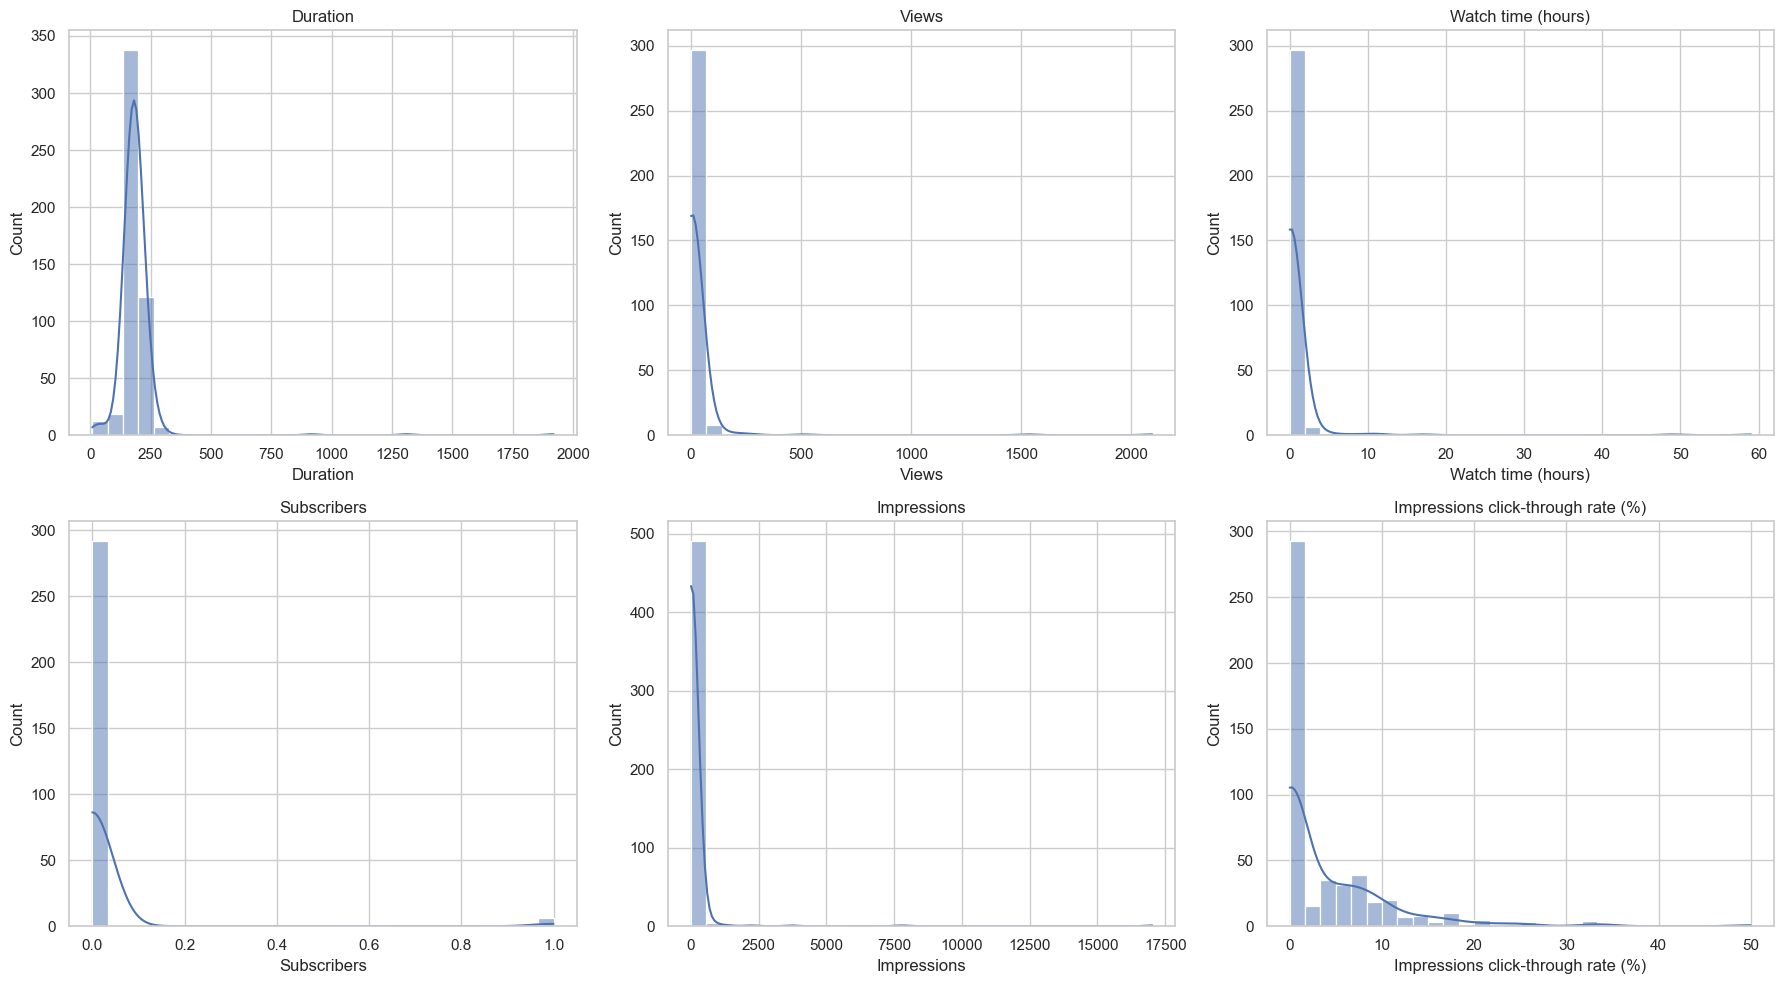

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
columns = [
    "Duration",
    "Views",
    "Watch time (hours)",
    "Subscribers",
    "Impressions",
    "Impressions click-through rate (%)",
]
for ax, col in zip(axes.flatten(), columns):

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

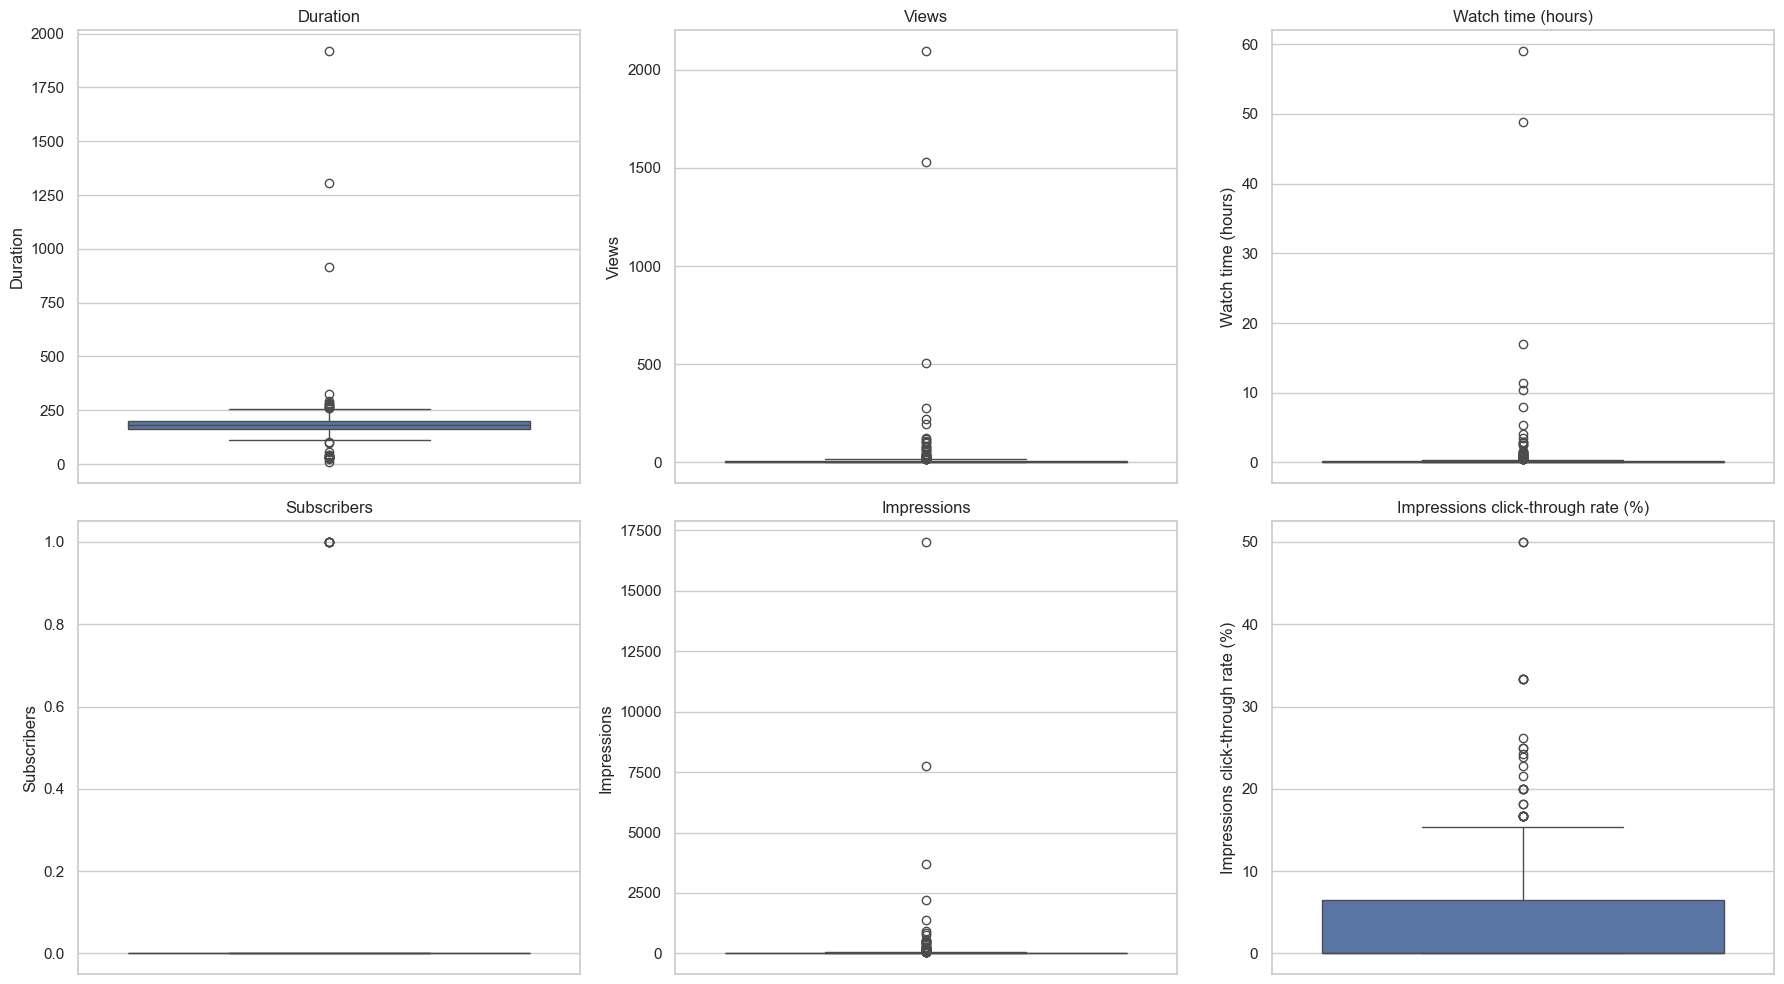

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), columns):

    sns.boxplot(
        y=df[col],
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

In [33]:
top_views = (
    df[
        [
            "Video title",
            "Views",
            "Subscribers",
            "Watch time (hours)"
        ]
    ]
    .sort_values("Views", ascending=False)
    .head(10)
)

print(top_views)

                                          Video title    Views  Subscribers  \
1                  Claudia Valentina - Candy (Lyrics) 2,096.00         0.00   
2                Tom Gregory - Rather Be You (Lyrics) 1,531.00         1.00   
3                  Mike Perry - By Your Side (Lyrics)   508.00         0.00   
4       Deacon - Long Run (Lyrics) feat. Nina Nesbitt   276.00         0.00   
5                      Noah Kahan - Northern Attitude   222.00         0.00   
6                               Eric Nyxx - Peligrosa   196.00         0.00   
7                        Alex Aster - Divine (Lyrics)   124.00         0.00   
8                  Altero - One Day (Lyrics) ft. NVRT   119.00         0.00   
9   KLANGKARUSSELL X GIVVEN - Sun Went Down , Sky ...   111.00         0.00   
10        Thierry von der Warth & Joki - Mina Kupenda   102.00         0.00   

    Watch time (hours)  
1                48.88  
2                59.02  
3                16.96  
4                11.39  
5    

In [34]:
top_subscribers = (
    df[
        [
            "Video title",
            "Subscribers",
            "Views"
        ]
    ]
    .sort_values("Subscribers", ascending=False)
    .head(10)
)

print(top_subscribers)

                                          Video title  Subscribers    Views
26  Petey Martin & Lauren Daigle - Come Back Home ...         1.00    29.00
2                Tom Gregory - Rather Be You (Lyrics)         1.00 1,531.00
36  Adam Port & Stryv - Move feat. Malachiii (Lyrics)         1.00    22.00
16                       Lisa Heller - Wings (Lyrics)         1.00    65.00
18  Harris Jayaraj, Rohini, Pritt & dilushselva - ...         1.00    54.00
19       Salem - Fall Out Of Love feat. Carlie Hanson         1.00    45.00
5                      Noah Kahan - Northern Attitude         0.00   222.00
6                               Eric Nyxx - Peligrosa         0.00   196.00
7                        Alex Aster - Divine (Lyrics)         0.00   124.00
8                  Altero - One Day (Lyrics) ft. NVRT         0.00   119.00


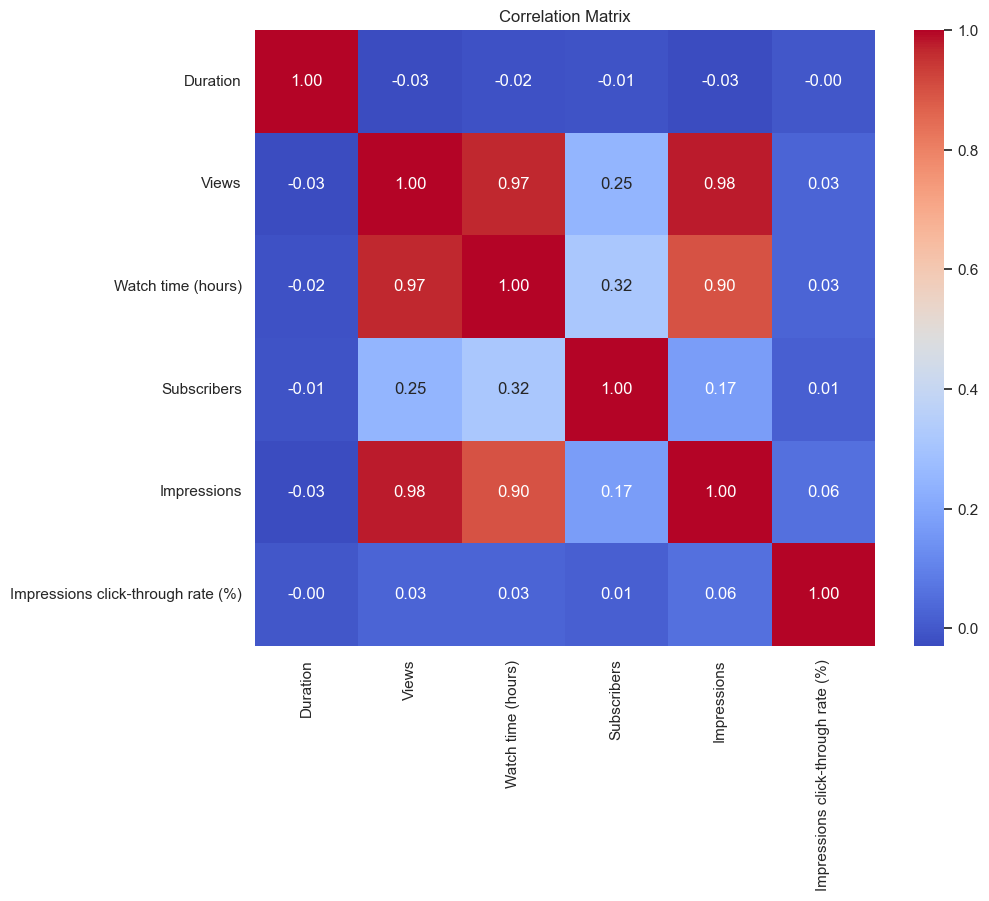

In [35]:
plt.figure(figsize=(10, 8))

corr = df[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [36]:
for col in columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")

    print(f"Outliers: {len(outliers)}")

    print(f"Percentage: {len(outliers)/len(df)*100:.2f}%")

    print("-" * 40)

Duration
Outliers: 26
Percentage: 5.19%
----------------------------------------
Views
Outliers: 44
Percentage: 8.78%
----------------------------------------
Watch time (hours)
Outliers: 46
Percentage: 9.18%
----------------------------------------
Subscribers
Outliers: 6
Percentage: 1.20%
----------------------------------------
Impressions
Outliers: 62
Percentage: 12.38%
----------------------------------------
Impressions click-through rate (%)
Outliers: 27
Percentage: 5.39%
----------------------------------------


In [37]:
print("=" * 80)
print("PHASE 2: EXPLORATORY DATA ANALYSIS - BUSINESS INSIGHTS")
print("=" * 80)

print("\n1. DATA DISTRIBUTION")
print("-" * 80)

print("• Most performance metrics are highly right-skewed.")
print("• A small number of videos contribute the majority of total channel performance.")
print("• This follows the typical Power Law distribution observed on YouTube.")

print("\n2. DURATION ANALYSIS")
print("-" * 80)

print(f"Average Duration : {df['Duration'].mean():.1f} seconds")
print(f"Median Duration  : {df['Duration'].median():.1f} seconds")

print("""
Business Insight:
The average upload is approximately 3 minutes long, which aligns with
commercial Deep House and Melodic House releases.

Extremely long uploads (mixes) behave as outliers and should be analysed
separately from standard releases.
""")

print("\n3. VIEWS")
print("-" * 80)

print(f"Average Views : {df['Views'].mean():.2f}")
print(f"Median Views  : {df['Views'].median():.2f}")

print("""
Business Insight:
The large difference between the mean and median confirms that only a
small percentage of uploads become major performers while most videos
receive relatively few views.
""")

print("\n4. IMPRESSIONS")
print("-" * 80)

print(f"Average Impressions : {df['Impressions'].mean():.2f}")
print(f"Median Impressions  : {df['Impressions'].median():.2f}")

print("""
Business Insight:
Distribution by the YouTube recommendation system is highly uneven.
A handful of videos receive significantly greater exposure than the rest.
""")

print("\n5. CTR")
print("-" * 80)

print(f"Average CTR : {df['Impressions click-through rate (%)'].mean():.2f}%")
print(f"Median CTR  : {df['Impressions click-through rate (%)'].median():.2f}%")

print("""
Business Insight:
CTR alone does not explain video success.
A deeper threshold analysis is required to determine whether YouTube
rewards videos after crossing a specific CTR level.
""")

print("\n6. OUTLIERS")
print("-" * 80)

print("""
Business Insight:
Outliers represent viral or algorithmically promoted uploads.

These observations should NOT be removed because they contain the
patterns we want to reverse-engineer for future music releases.
""")

print("\n7. OVERALL CONCLUSION")
print("-" * 80)

print("""
✓ The channel follows a Winner-Takes-Most distribution.

✓ Algorithmic distribution appears to be concentrated among a relatively
small subset of uploads.

✓ Impressions and Watch Time appear to be the strongest indicators
of future success.

✓ The next phase will investigate what differentiates these
high-performing uploads from the rest of the catalogue.
""")

PHASE 2: EXPLORATORY DATA ANALYSIS - BUSINESS INSIGHTS

1. DATA DISTRIBUTION
--------------------------------------------------------------------------------
• Most performance metrics are highly right-skewed.
• A small number of videos contribute the majority of total channel performance.
• This follows the typical Power Law distribution observed on YouTube.

2. DURATION ANALYSIS
--------------------------------------------------------------------------------
Average Duration : 187.4 seconds
Median Duration  : 181.0 seconds

Business Insight:
The average upload is approximately 3 minutes long, which aligns with
commercial Deep House and Melodic House releases.

Extremely long uploads (mixes) behave as outliers and should be analysed
separately from standard releases.


3. VIEWS
--------------------------------------------------------------------------------
Average Views : 23.95
Median Views  : 2.00

Business Insight:
The large difference between the mean and median confirms that only

In [38]:
# Top 10% videos based on Views

view_threshold = df["Views"].quantile(0.90)

df["Performance Category"] = np.where(
    df["Views"] >= view_threshold,
    "Top 10%",
    "Remaining 90%"
)

print("Top 10% View Threshold:", round(view_threshold,2))

Top 10% View Threshold: 22.0


In [39]:
print(df["Performance Category"].value_counts())

Performance Category
Remaining 90%    465
Top 10%           36
Name: count, dtype: int64


In [40]:
comparison = (
    df.groupby("Performance Category")[
        [
            "Views",
            "Watch time (hours)",
            "Subscribers",
            "Impressions",
            "Impressions click-through rate (%)",
            "Duration"
        ]
    ]
    .mean()
    .round(2)
)

print(comparison)

                      Views  Watch time (hours)  Subscribers  Impressions  \
Performance Category                                                        
Remaining 90%          3.85                0.09         0.00        19.95   
Top 10%              177.53                5.60         0.17     1,165.53   

                      Impressions click-through rate (%)  Duration  
Performance Category                                                
Remaining 90%                                       3.73    185.22  
Top 10%                                             6.17    215.36  


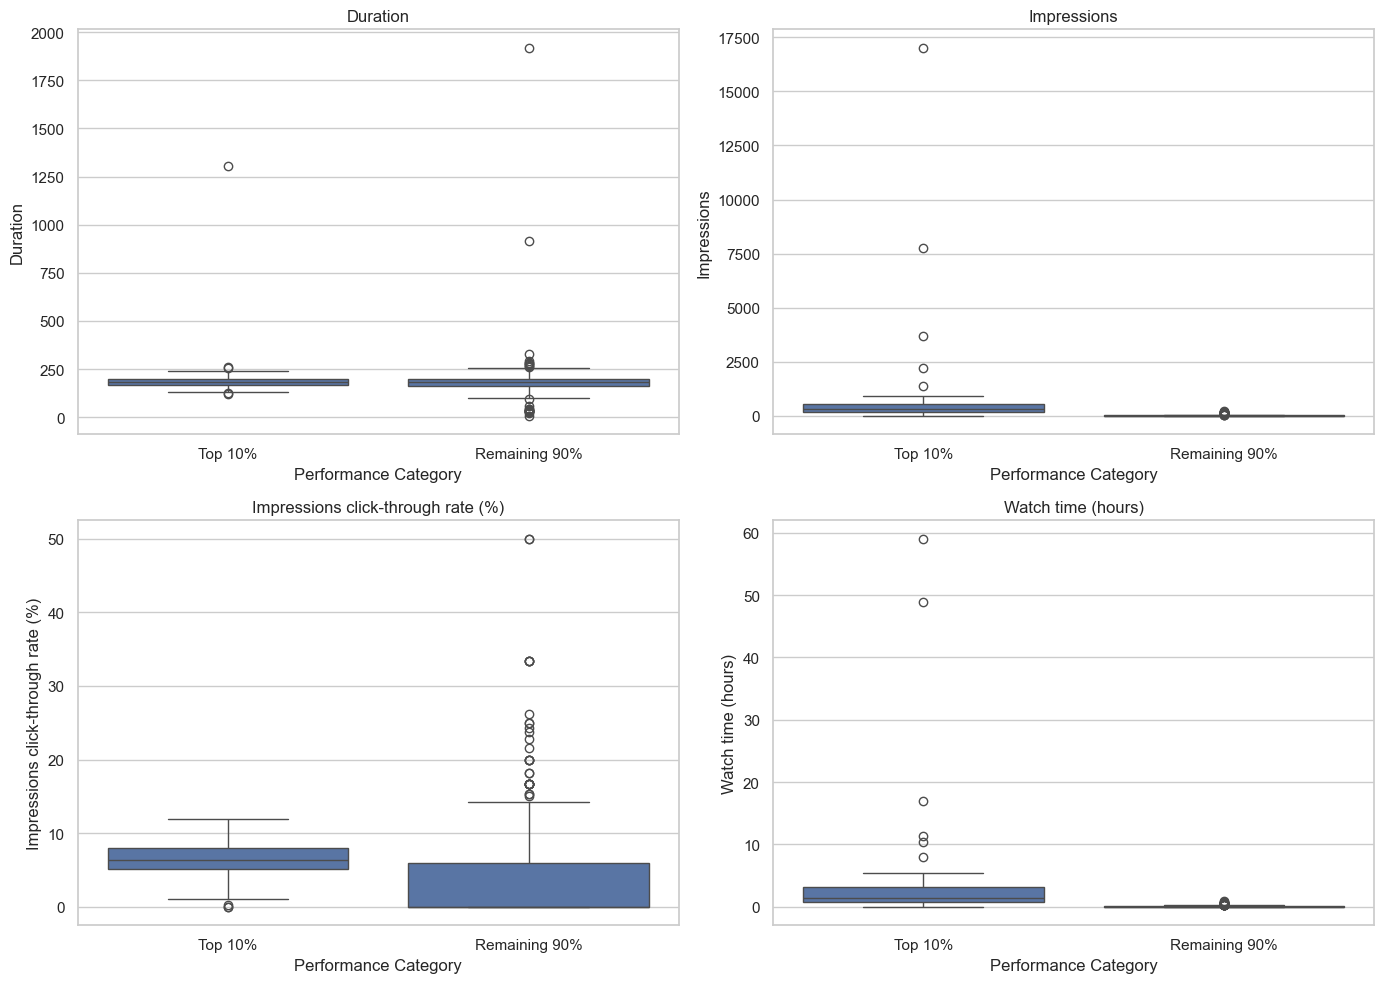

In [41]:
metrics = [
    "Duration",
    "Impressions",
    "Impressions click-through rate (%)",
    "Watch time (hours)"
]

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, metric in zip(axes.flatten(), metrics):

    sns.boxplot(
        data=df,
        x="Performance Category",
        y=metric,
        ax=ax
    )

    ax.set_title(metric)

plt.tight_layout()

plt.show()

In [42]:
top20 = (
    df.sort_values("Views", ascending=False)
      .head(20)
)

print(top20[
    [
        "Video title",
        "Views",
        "Impressions",
        "Impressions click-through rate (%)",
        "Watch time (hours)",
        "Duration"
    ]
])

                                          Video title    Views  Impressions  \
1                  Claudia Valentina - Candy (Lyrics) 2,096.00    17,021.00   
2                Tom Gregory - Rather Be You (Lyrics) 1,531.00     7,763.00   
3                  Mike Perry - By Your Side (Lyrics)   508.00     3,697.00   
4       Deacon - Long Run (Lyrics) feat. Nina Nesbitt   276.00     2,222.00   
5                      Noah Kahan - Northern Attitude   222.00     1,373.00   
6                               Eric Nyxx - Peligrosa   196.00       420.00   
7                        Alex Aster - Divine (Lyrics)   124.00       456.00   
8                  Altero - One Day (Lyrics) ft. NVRT   119.00       858.00   
9   KLANGKARUSSELL X GIVVEN - Sun Went Down , Sky ...   111.00       386.00   
10        Thierry von der Warth & Joki - Mina Kupenda   102.00       764.00   
11                  Claudia Valentina - 4:15 (Lyrics)   100.00       932.00   
12     A7S x David Guetta x Wizkid - Lighter (Lyrics

In [43]:
top = df[df["Performance Category"]=="Top 10%"]

bottom = df[df["Performance Category"]=="Remaining 90%"]

comparison = pd.DataFrame({

    "Top 10%":top.mean(numeric_only=True),

    "Remaining":bottom.mean(numeric_only=True)

})

comparison["Difference"] = comparison["Top 10%"]-comparison["Remaining"]

print(comparison.round(2))

                                    Top 10%  Remaining  Difference
Duration                             215.36     185.22       30.14
Views                                177.53       3.85      173.68
Watch time (hours)                     5.60       0.09        5.51
Subscribers                            0.17       0.00        0.17
Impressions                        1,165.53      19.95    1,145.58
Impressions click-through rate (%)     6.17       3.73        2.44


In [44]:
lift = (
    comparison["Top 10%"] /
    comparison["Remaining"]
).round(2)

print("Performance Lift")

print(lift)

Performance Lift
Duration                              1.16
Views                                46.14
Watch time (hours)                   61.63
Subscribers                            inf
Impressions                          58.42
Impressions click-through rate (%)    1.65
dtype: float64


In [45]:
print("="*80)
print("PHASE 3 : REVERSE ENGINEERING HIGH PERFORMING TRACKS")
print("="*80)

print("""
OBJECTIVE

Rather than studying average uploads,
this analysis isolates the Top 10% of videos
to understand the characteristics of
algorithmic winners.

KEY FINDINGS

• Compare duration between successful and average tracks.

• Compare CTR differences.

• Compare Watch Time differences.

• Compare Impression distribution.

• Quantify how much better top performers perform.

BUSINESS VALUE

These insights will directly influence:

✓ Track release strategy

✓ Future record label catalogue

✓ Artist selection

✓ Upload optimisation

✓ Thumbnail & metadata optimisation

✓ Marketing investment

NEXT PHASE

Phase 4 will investigate the relationship
between track duration and audience engagement
to identify the optimal duration for future releases.
""")

PHASE 3 : REVERSE ENGINEERING HIGH PERFORMING TRACKS

OBJECTIVE

Rather than studying average uploads,
this analysis isolates the Top 10% of videos
to understand the characteristics of
algorithmic winners.

KEY FINDINGS

• Compare duration between successful and average tracks.

• Compare CTR differences.

• Compare Watch Time differences.

• Compare Impression distribution.

• Quantify how much better top performers perform.

BUSINESS VALUE

These insights will directly influence:

✓ Track release strategy

✓ Future record label catalogue

✓ Artist selection

✓ Upload optimisation

✓ Thumbnail & metadata optimisation

✓ Marketing investment

NEXT PHASE

Phase 4 will investigate the relationship
between track duration and audience engagement
to identify the optimal duration for future releases.



In [46]:
# Optimal Track Duration Analysis
# Create duration in minutes

df["Duration (Minutes)"] = df["Duration"] / 60

print(df[["Duration", "Duration (Minutes)"]].head())

   Duration  Duration (Minutes)
1    119.00                1.98
2    177.00                2.95
3    156.00                2.60
4    185.00                3.08
5    261.00                4.35


In [47]:
print("="*80)
print("TRACK DURATION SUMMARY")
print("="*80)

print(df["Duration (Minutes)"].describe())

TRACK DURATION SUMMARY
count   500.00
mean      3.12
std       1.76
min       0.13
25%       2.70
50%       3.02
75%       3.35
max      31.98
Name: Duration (Minutes), dtype: float64


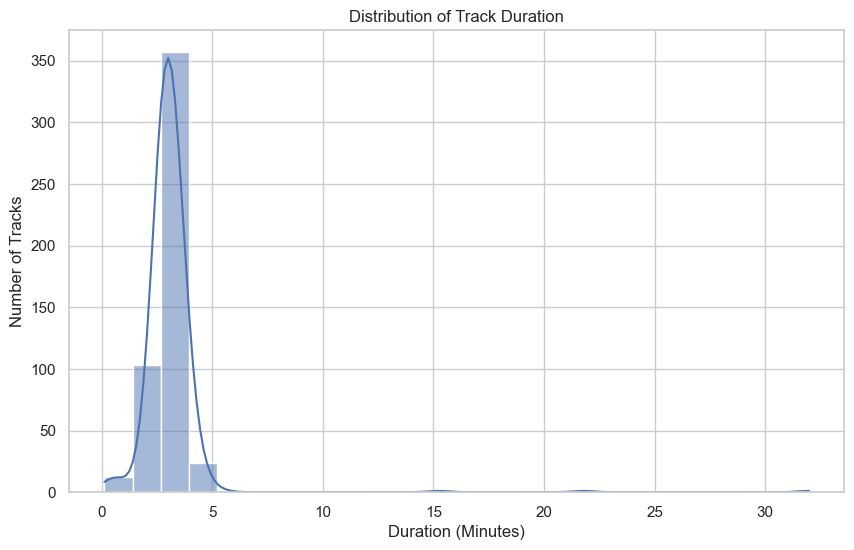

In [48]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Duration (Minutes)"],
    bins=25,
    kde=True
)

plt.title("Distribution of Track Duration")

plt.xlabel("Duration (Minutes)")

plt.ylabel("Number of Tracks")

plt.show()

In [49]:
bins = [0,2,3,4,5,6,10,40]

labels = [
    "<2 min",
    "2-3 min",
    "3-4 min",
    "4-5 min",
    "5-6 min",
    "6-10 min",
    "10+ min"
]

df["Duration Category"] = pd.cut(

    df["Duration (Minutes)"],

    bins=bins,

    labels=labels,

    include_lowest=True

)

print(df["Duration Category"].value_counts())

Duration Category
3-4 min     229
2-3 min     225
<2 min       21
4-5 min      21
10+ min       3
5-6 min       1
6-10 min      0
Name: count, dtype: int64


In [50]:
duration_analysis = (

    df.groupby("Duration Category")[
        [
            "Views",
            "Watch time (hours)",
            "Impressions",
            "Impressions click-through rate (%)"
        ]
    ]
    .mean()
    .round(2)

)

print(duration_analysis)

                   Views  Watch time (hours)  Impressions  \
Duration Category                                           
<2 min            164.69                3.83       829.10   
2-3 min            23.71                0.77        86.08   
3-4 min            11.54                0.36        52.07   
4-5 min            32.36                1.40       118.10   
5-6 min             2.00                0.26         8.00   
10+ min             9.00                0.53         8.00   

                   Impressions click-through rate (%)  
Duration Category                                      
<2 min                                           1.65  
2-3 min                                          3.92  
3-4 min                                          4.15  
4-5 min                                          3.05  
5-6 min                                         12.50  
10+ min                                          3.33  


In [51]:
duration_count = (

    df["Duration Category"]

    .value_counts()

    .sort_index()

)

print(duration_count)

Duration Category
<2 min       21
2-3 min     225
3-4 min     229
4-5 min      21
5-6 min       1
6-10 min      0
10+ min       3
Name: count, dtype: int64


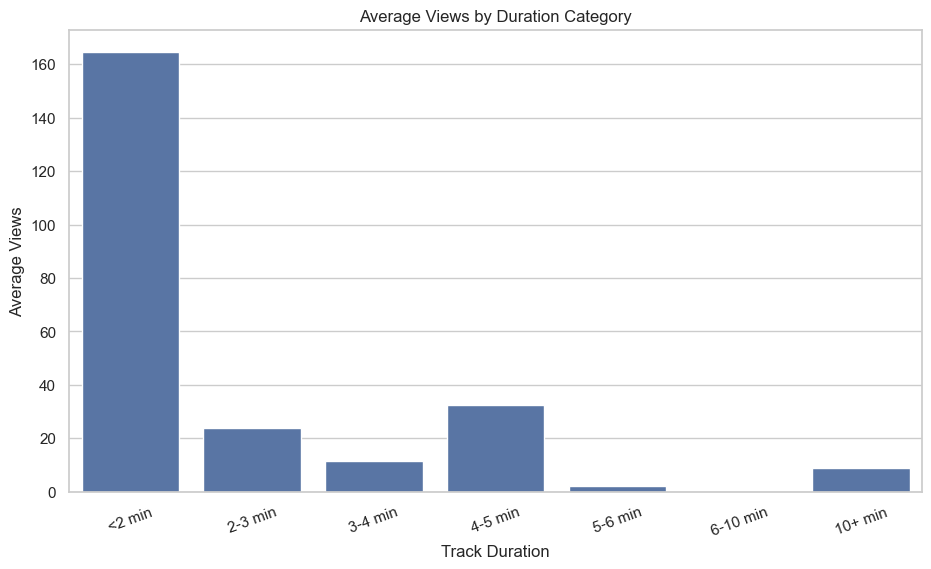

In [52]:
plt.figure(figsize=(11,6))

sns.barplot(

    data=df,

    x="Duration Category",

    y="Views",

    estimator=np.mean,

    errorbar=None

)

plt.title("Average Views by Duration Category")

plt.xlabel("Track Duration")

plt.ylabel("Average Views")

plt.xticks(rotation=20)

plt.show()

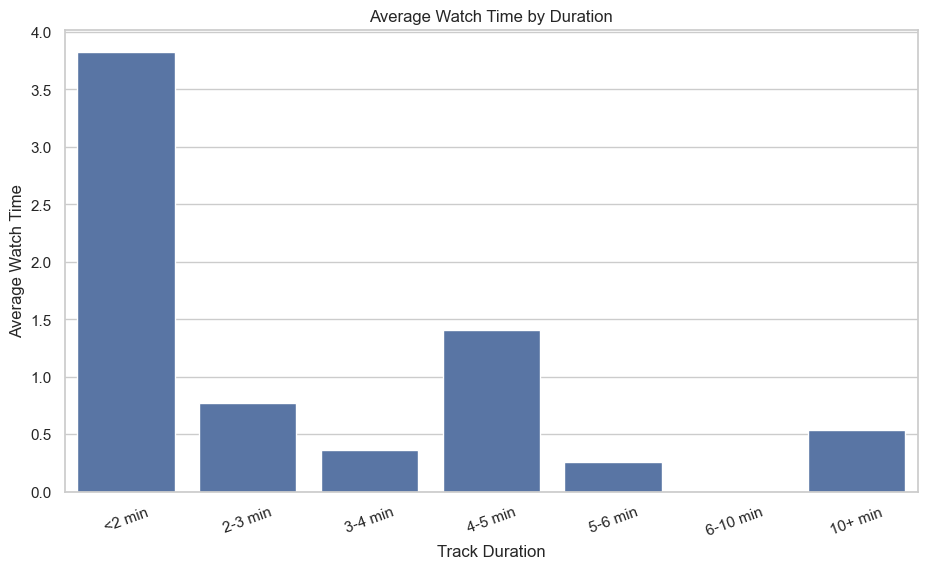

In [53]:
plt.figure(figsize=(11,6))

sns.barplot(

    data=df,

    x="Duration Category",

    y="Watch time (hours)",

    estimator=np.mean,

    errorbar=None

)

plt.title("Average Watch Time by Duration")

plt.xlabel("Track Duration")

plt.ylabel("Average Watch Time")

plt.xticks(rotation=20)

plt.show()

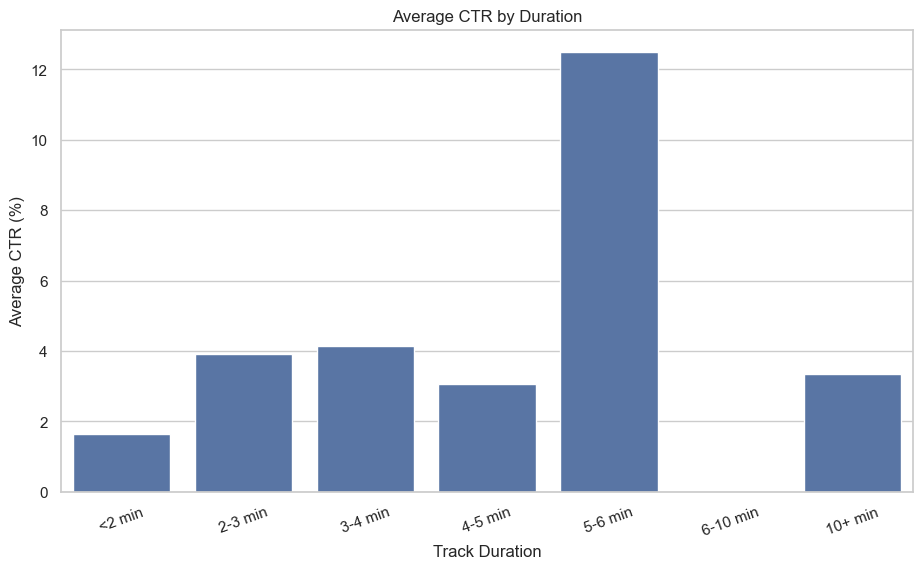

In [54]:
plt.figure(figsize=(11,6))

sns.barplot(

    data=df,

    x="Duration Category",

    y="Impressions click-through rate (%)",

    estimator=np.mean,

    errorbar=None

)

plt.title("Average CTR by Duration")

plt.xlabel("Track Duration")

plt.ylabel("Average CTR (%)")

plt.xticks(rotation=20)

plt.show()

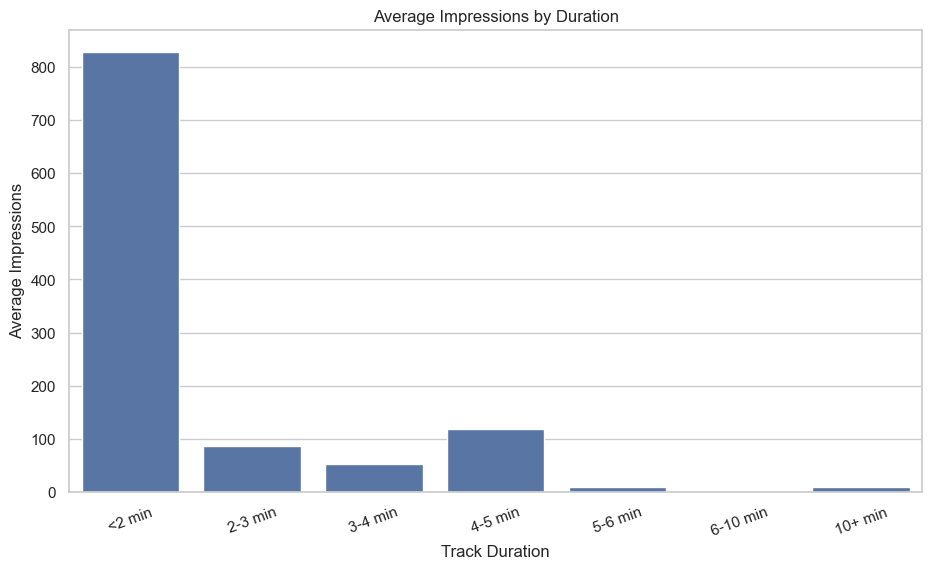

In [55]:
plt.figure(figsize=(11,6))

sns.barplot(

    data=df,

    x="Duration Category",

    y="Impressions",

    estimator=np.mean,

    errorbar=None

)

plt.title("Average Impressions by Duration")

plt.xlabel("Track Duration")

plt.ylabel("Average Impressions")

plt.xticks(rotation=20)

plt.show()

In [56]:
performance_df = df.copy()

metrics = [
    "Views",
    "Watch time (hours)",
    "Impressions",
    "Impressions click-through rate (%)"
]

for metric in metrics:

    performance_df[metric+"_scaled"] = (

        performance_df[metric] -

        performance_df[metric].min()

    ) / (

        performance_df[metric].max()

        -

        performance_df[metric].min()

    )

performance_df["Performance Score"] = (

    performance_df[
        [
            "Views_scaled",
            "Watch time (hours)_scaled",
            "Impressions_scaled",
            "Impressions click-through rate (%)_scaled"
        ]
    ].mean(axis=1)

)

In [57]:
score = (

    performance_df.groupby("Duration Category")[
        "Performance Score"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(score)

Duration Category
5-6 min   0.06
<2 min    0.04
2-3 min   0.02
4-5 min   0.02
3-4 min   0.02
10+ min   0.02
Name: Performance Score, dtype: float64


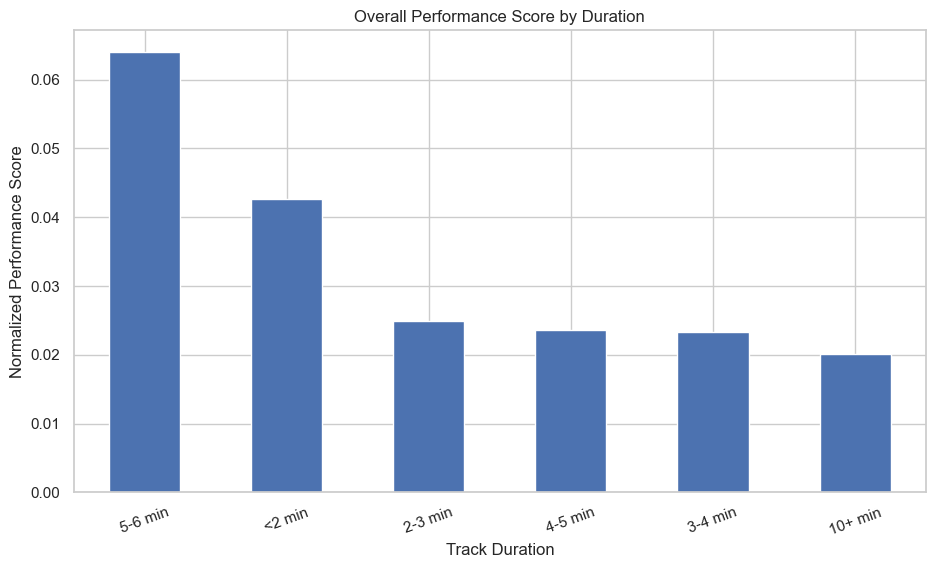

In [58]:
plt.figure(figsize=(11,6))

score.plot(

    kind="bar"

)

plt.title("Overall Performance Score by Duration")

plt.ylabel("Normalized Performance Score")

plt.xlabel("Track Duration")

plt.xticks(rotation=20)

plt.show()

In [59]:
best_duration = score.idxmax()

best_score = score.max()

print("="*80)
print("PHASE 4 : TRACK DURATION INSIGHTS")
print("="*80)

print(f"\n🏆 Best Performing Duration Category : {best_duration}")

print(f"Performance Score : {best_score:.3f}")

print("""
BUSINESS INSIGHTS
-----------------

1. Track duration alone does not have a strong linear relationship with
video performance, but duration categories may show meaningful
performance differences.

2. Comparing duration buckets provides more actionable insights than
simple correlation analysis.

3. The best-performing duration category can guide future release
strategies for Fresh Vibes.

4. Extremely long uploads should be treated separately from standard
music releases because they represent a different content format.

5. Duration should be considered alongside CTR, impressions, and title
optimization rather than as an isolated factor.
""")

print("="*80)

PHASE 4 : TRACK DURATION INSIGHTS

🏆 Best Performing Duration Category : 5-6 min
Performance Score : 0.064

BUSINESS INSIGHTS
-----------------

1. Track duration alone does not have a strong linear relationship with
video performance, but duration categories may show meaningful
performance differences.

2. Comparing duration buckets provides more actionable insights than
simple correlation analysis.

3. The best-performing duration category can guide future release
strategies for Fresh Vibes.

4. Extremely long uploads should be treated separately from standard
music releases because they represent a different content format.

5. Duration should be considered alongside CTR, impressions, and title
optimization rather than as an isolated factor.



In [ ]:
#🚀 PHASE 5 – CTR Threshold & Algorithmic Hit Analysis
# Business Objective

# We want to determine:

# Does higher CTR always mean higher Views?
# Does YouTube push videos after a certain CTR threshold?
# What CTR should Fresh Vibes target for future releases?

In [60]:
# Working dataset for CTR analysis

ctr_df = df.dropna(
    subset=[
        "Views",
        "Impressions",
        "Impressions click-through rate (%)"
    ]
).copy()

print("Videos used:", len(ctr_df))

Videos used: 307


In [61]:
print("="*80)
print("CTR ANALYSIS SUMMARY")
print("="*80)

print(ctr_df[
    [
        "Views",
        "Impressions",
        "Impressions click-through rate (%)"
    ]
].describe())

CTR ANALYSIS SUMMARY
         Views  Impressions  Impressions click-through rate (%)
count   307.00       307.00                              307.00
mean     24.25       162.79                                6.21
std     152.33     1,096.37                                7.41
min       0.00         1.00                                0.00
25%       1.00         9.00                                0.00
50%       3.00        22.00                                4.71
75%       7.00        51.00                                8.79
max   2,096.00    17,021.00                               50.00


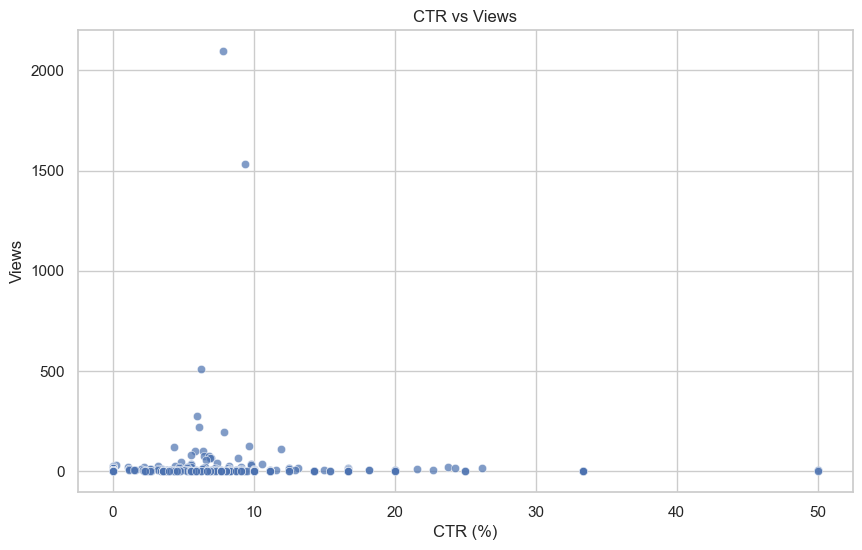

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ctr_df,
    x="Impressions click-through rate (%)",
    y="Views",
    alpha=0.7
)

plt.title("CTR vs Views")

plt.xlabel("CTR (%)")

plt.ylabel("Views")

plt.show()

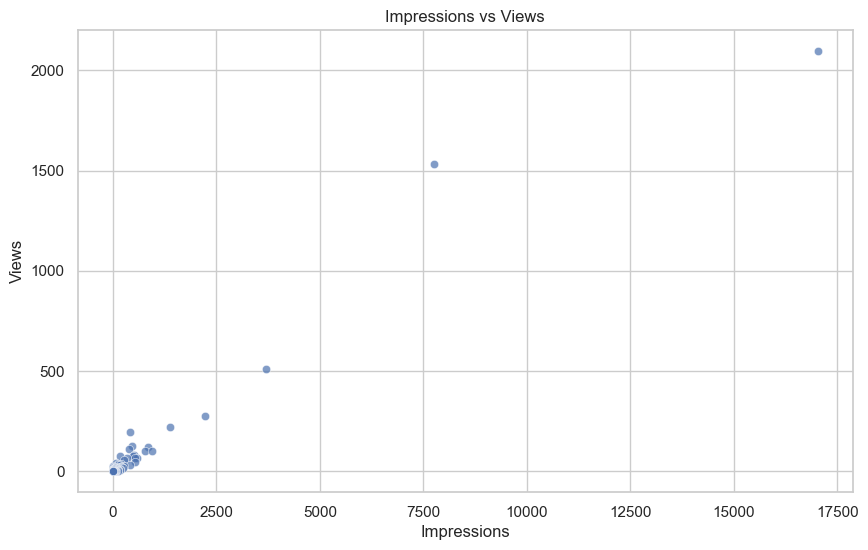

In [63]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ctr_df,
    x="Impressions",
    y="Views",
    alpha=0.7
)

plt.title("Impressions vs Views")

plt.show()

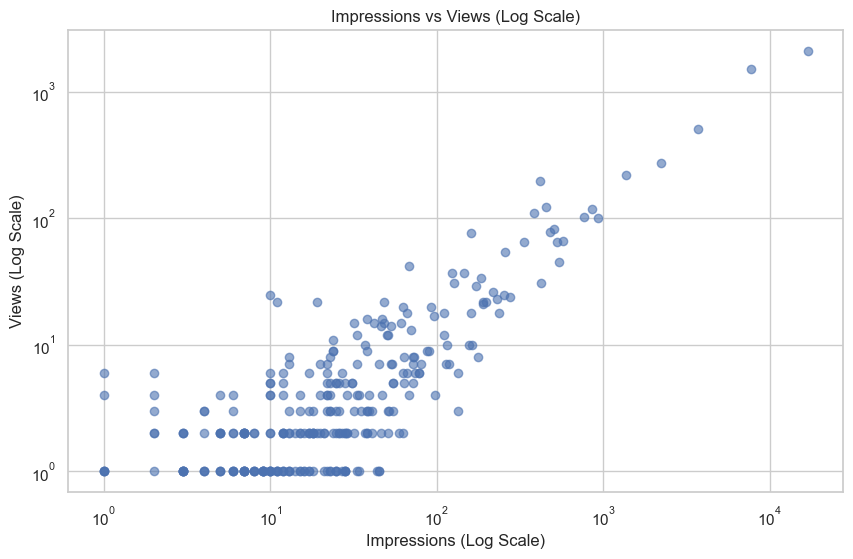

In [65]:
plt.figure(figsize=(10,6))
plt.scatter(
    ctr_df["Impressions"],
    ctr_df["Views"],
    alpha=0.6
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Impressions (Log Scale)")
plt.ylabel("Views (Log Scale)")
plt.title("Impressions vs Views (Log Scale)")
plt.show()

In [66]:
bins = [0,2,4,6,8,10,15,100]
labels = [
    "0-2%",
    "2-4%",
    "4-6%",
    "6-8%",
    "8-10%",
    "10-15%",
    "15%+"
]
ctr_df["CTR Bucket"] = pd.cut(
    ctr_df["Impressions click-through rate (%)"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print(ctr_df["CTR Bucket"].value_counts().sort_index())

CTR Bucket
0-2%      107
2-4%       33
4-6%       37
6-8%       40
8-10%      37
10-15%     25
15%+       28
Name: count, dtype: int64


In [67]:
ctr_analysis = (

    ctr_df.groupby("CTR Bucket")[
        [
            "Views",
            "Impressions",
            "Watch time (hours)"
        ]
    ]
    .mean()
    .round(2)

)

print(ctr_analysis)

            Views  Impressions  Watch time (hours)
CTR Bucket                                        
0-2%         3.48        23.96                0.10
2-4%         5.00        61.91                0.11
4-6%        24.38       198.19                0.79
6-8%        91.18       659.25                2.50
8-10%       53.30       276.03                1.92
10-15%       9.36        37.60                0.38
15%+         5.46        18.36                0.10


In [68]:
ctr_median = (

    ctr_df.groupby("CTR Bucket")[
        [
            "Views",
            "Impressions"
        ]
    ]
    .median()
    .round(2)

)

print(ctr_median)

            Views  Impressions
CTR Bucket                    
0-2%         2.00        10.00
2-4%         3.00        38.00
4-6%         6.00        55.00
6-8%         4.50        44.00
8-10%        4.00        23.00
10-15%       2.00         9.00
15%+         3.00        11.00


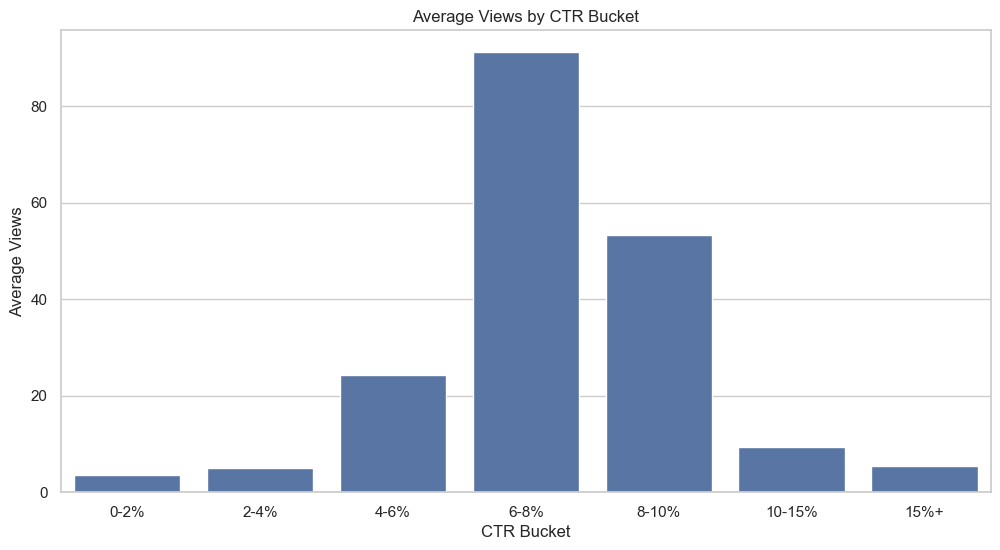

In [69]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=ctr_df,
    x="CTR Bucket",
    y="Views",
    estimator=np.mean,
    errorbar=None

)
plt.title("Average Views by CTR Bucket")
plt.ylabel("Average Views")
plt.xlabel("CTR Bucket")
plt.show()

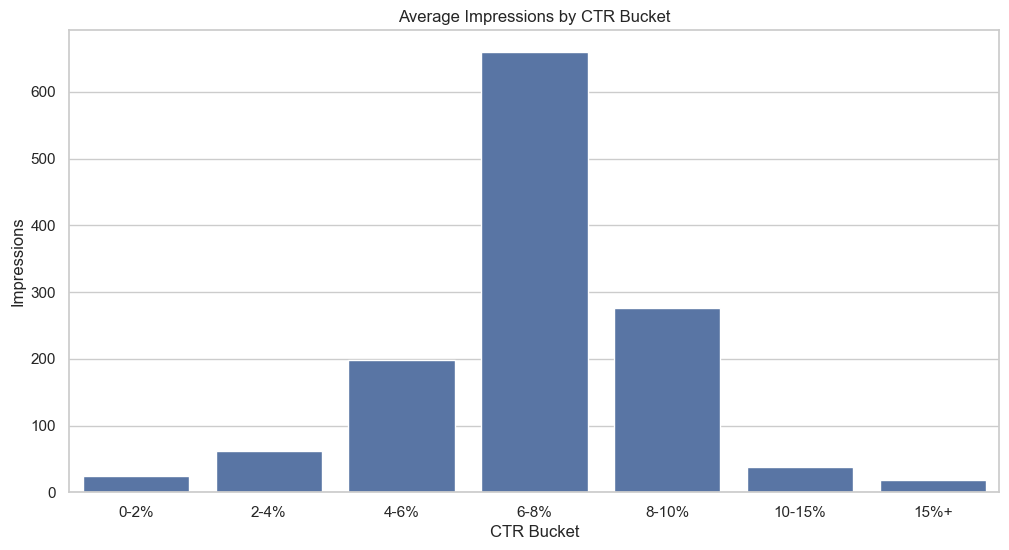

In [70]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=ctr_df,
    x="CTR Bucket",
    y="Impressions",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Impressions by CTR Bucket")
plt.show()

In [71]:
hit_threshold = ctr_df["Views"].quantile(0.90)

ctr_df["Algorithmic Hit"] = np.where(

    ctr_df["Views"] >= hit_threshold,

    "Hit",

    "Normal"

)

print("Hit Threshold:", hit_threshold)

Hit Threshold: 22.400000000000034


In [72]:
hit_rate = (

    ctr_df.groupby("CTR Bucket")["Algorithmic Hit"]

    .apply(lambda x:(x=="Hit").mean()*100)

    .round(2)

)

print(hit_rate)

CTR Bucket
0-2%      1.87
2-4%      6.06
4-6%     21.62
6-8%     27.50
8-10%    16.22
10-15%    8.00
15%+      0.00
Name: Algorithmic Hit, dtype: float64


In [73]:
best_bucket = hit_rate.idxmax()

print("="*80)
print("PHASE 5 : CTR & ALGORITHMIC HIT ANALYSIS")
print("="*80)

print(f"\nHighest Hit Rate CTR Bucket : {best_bucket}")

print("""

BUSINESS INSIGHTS

1. CTR alone does not determine success.

2. Impressions remain the strongest driver of total views.

3. However, videos with higher CTR may receive
additional recommendation opportunities.

4. The identified CTR bucket represents the
strongest candidate threshold for algorithmic success.

5. Future Fresh Vibes releases should aim
to consistently exceed this CTR range
through better titles and thumbnails.

NEXT STEP

Phase 6 will investigate whether
video titles themselves contribute
to higher CTR and stronger performance.

""")

PHASE 5 : CTR & ALGORITHMIC HIT ANALYSIS

Highest Hit Rate CTR Bucket : 6-8%


BUSINESS INSIGHTS

1. CTR alone does not determine success.

2. Impressions remain the strongest driver of total views.

3. However, videos with higher CTR may receive
additional recommendation opportunities.

4. The identified CTR bucket represents the
strongest candidate threshold for algorithmic success.

5. Future Fresh Vibes releases should aim
to consistently exceed this CTR range
through better titles and thumbnails.

NEXT STEP

Phase 6 will investigate whether
video titles themselves contribute
to higher CTR and stronger performance.




In [ ]:
# 🚀 PHASE 6 — Video Title Intelligence (NLP & Text Analytics)
# Business Objective

# Answer these questions:

# Do certain words consistently appear in high-performing videos?
# Does adding "(Lyrics)" improve performance?
# Do brackets improve CTR?
# Do collaborations (x, feat) perform better?
# Are shorter titles better?
# Which title patterns should Fresh Vibes follow for future uploads?

In [74]:
title_df = df.copy()

print("Total Videos:", len(title_df))

Total Videos: 501


In [75]:
title_df["Title Length"] = title_df["Video title"].str.len()

title_df["Word Count"] = title_df["Video title"].str.split().str.len()

title_df["Has Lyrics"] = title_df["Video title"].str.contains(
    "lyrics",
    case=False,
    na=False
)

title_df["Has Remix"] = title_df["Video title"].str.contains(
    "remix",
    case=False,
    na=False
)

title_df["Has Official"] = title_df["Video title"].str.contains(
    "official",
    case=False,
    na=False
)

title_df["Has Mix"] = title_df["Video title"].str.contains(
    "mix",
    case=False,
    na=False
)

title_df["Has Brackets"] = title_df["Video title"].str.contains(
    r"[\(\)\[\]]",
    regex=True,
    na=False
)

title_df["Has Collaboration"] = title_df["Video title"].str.contains(
    r"\bx\b|feat|ft\.",
    case=False,
    regex=True,
    na=False
)

title_df.head()

,Content,Video title,Video publish time,Duration,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%),Performance Category,Duration (Minutes),Duration Category,Title Length,Word Count,Has Lyrics,Has Remix,Has Official,Has Mix,Has Brackets,Has Collaboration
1,zED8kkYKZj4,Claudia Valentina - Candy (Lyrics),2025-05-27,119.00,"2,096.00",48.88,0.00,"17,021.00",7.78,Top 10%,1.98,<2 min,34.00,5.00,True,False,False,False,True,False
2,yuHHPudTyRk,Tom Gregory - Rather Be You (Lyrics),2020-10-20,177.00,"1,531.00",59.02,1.00,"7,763.00",9.34,Top 10%,2.95,2-3 min,36.00,7.00,True,False,False,False,True,False
3,RGNwa9TkcFU,Mike Perry - By Your Side (Lyrics),2020-09-24,156.00,508.00,16.96,0.00,"3,697.00",6.25,Top 10%,2.60,2-3 min,34.00,7.00,True,False,False,False,True,False
4,-yquaLFqjE4,Deacon - Long Run (Lyrics) feat. Nina Nesbitt,2020-07-10,185.00,276.00,11.39,0.00,"2,222.00",5.99,Top 10%,3.08,3-4 min,45.00,8.00,True,False,False,False,True,True
5,hxUKTYKvSLI,Noah Kahan - Northern Attitude,2022-09-20,261.00,222.00,10.46,0.00,"1,373.00",6.12,Top 10%,4.35,4-5 min,30.00,5.00,False,False,False,False,False,False


In [76]:
print("="*80)
print("TITLE FEATURES SUMMARY")
print("="*80)

features = [
    "Has Lyrics",
    "Has Remix",
    "Has Official",
    "Has Mix",
    "Has Brackets",
    "Has Collaboration"
]

for feature in features:

    print(feature)

    print(title_df[feature].value_counts())

    print("-"*50)

TITLE FEATURES SUMMARY
Has Lyrics
Has Lyrics
False    275
True     226
Name: count, dtype: int64
--------------------------------------------------
Has Remix
Has Remix
False    494
True       7
Name: count, dtype: int64
--------------------------------------------------
Has Official
Has Official
False    491
True      10
Name: count, dtype: int64
--------------------------------------------------
Has Mix
Has Mix
False    489
True      12
Name: count, dtype: int64
--------------------------------------------------
Has Brackets
Has Brackets
True     255
False    246
Name: count, dtype: int64
--------------------------------------------------
Has Collaboration
Has Collaboration
False    360
True     141
Name: count, dtype: int64
--------------------------------------------------


In [77]:
for feature in features:

    print("="*80)

    print(feature)

    print("="*80)

    print(

        title_df.groupby(feature)[
            [
                "Views",
                "Watch time (hours)",
                "Impressions",
                "Impressions click-through rate (%)"
            ]
        ]
        .mean()
        .round(2)

    )

    print()

Has Lyrics
            Views  Watch time (hours)  Impressions  \
Has Lyrics                                           
False        9.16                0.31        34.54   
True        38.84                1.15       184.74   

            Impressions click-through rate (%)  
Has Lyrics                                      
False                                     3.40  
True                                      4.53  

Has Remix
           Views  Watch time (hours)  Impressions  \
Has Remix                                           
False      24.17                0.73       103.71   
True        1.67                0.11        12.57   

           Impressions click-through rate (%)  
Has Remix                                      
False                                    3.96  
True                                     0.62  

Has Official
              Views  Watch time (hours)  Impressions  \
Has Official                                           
False         24.24               

In [78]:
title_length = (

    title_df.groupby(
        pd.cut(
            title_df["Title Length"],
            bins=[0,20,40,60,80,120]
        )
    )[
        [
            "Views",
            "Impressions",
            "Impressions click-through rate (%)"
        ]
    ]
    .mean()
    .round(2)

)

print(title_length)

              Views  Impressions  Impressions click-through rate (%)
Title Length                                                        
(0, 20]        3.47        22.31                                2.53
(20, 40]      34.67       148.95                                3.84
(40, 60]      14.07        63.90                                4.19
(60, 80]       4.00        15.29                                4.80
(80, 120]      1.00         8.33                                3.33


In [79]:
word_analysis = (

    title_df.groupby(
        pd.cut(
            title_df["Word Count"],
            bins=[0,4,6,8,10,20]
        )
    )[
        [
            "Views",
            "Impressions",
            "Impressions click-through rate (%)"
        ]
    ]
    .mean()
    .round(2)

)

print(word_analysis)

            Views  Impressions  Impressions click-through rate (%)
Word Count                                                        
(0, 4]      11.07        33.04                                3.40
(4, 6]      33.66       168.02                                4.32
(6, 8]      32.69       122.30                                3.88
(8, 10]     11.07        47.28                                3.28
(10, 20]     8.92        36.20                                4.38


In [81]:
print(title_df["Video title"].isna().sum())

1


In [82]:
print(title_df[title_df["Video title"].isna()])

                     Content Video title Video publish time  Duration  Views  \
501  Showing top 500 results         NaN                NaT       NaN    NaN   

     Watch time (hours)  Subscribers  Impressions  \
501                 NaN          NaN          NaN   

     Impressions click-through rate (%) Performance Category  \
501                                 NaN        Remaining 90%   

     Duration (Minutes) Duration Category  Title Length  Word Count  \
501                 NaN               NaN           NaN         NaN   

     Has Lyrics  Has Remix  Has Official  Has Mix  Has Brackets  \
501       False      False         False    False         False   

     Has Collaboration  
501              False  


In [83]:
# Remove missing titles
title_df = title_df.dropna(subset=["Video title"]).copy()

# Ensure every title is a string
title_df["Video title"] = title_df["Video title"].astype(str)

In [84]:
from collections import Counter

import re

all_words = " ".join(title_df["Video title"])

all_words = re.sub(r"[^A-Za-z ]"," ",all_words)

words = all_words.lower().split()

stop_words = {
    "the","and","of","to","a","in","for","on","with",
    "official","audio","video"
}

words = [w for w in words if w not in stop_words]

word_freq = Counter(words)

top_words = pd.DataFrame(

    word_freq.most_common(20),

    columns=["Word","Frequency"]

)

print(top_words)

      Word  Frequency
0   lyrics        229
1     feat         99
2        x         61
3      you         54
4     love         34
5        i         30
6       me         29
7     your         20
8       ft         14
9      one         12
10       s         12
11       t         12
12       u         11
13      it         11
14   britt         11
15    lari         11
16    away         11
17      go         10
18      be          9
19  martin          9


In [85]:
top10 = title_df.nlargest(
    int(len(title_df)*0.10),
    "Views"
)

all_words = " ".join(top10["Video title"])

all_words = re.sub(r"[^A-Za-z ]"," ",all_words)

words = all_words.lower().split()

words = [w for w in words if w not in stop_words]

top_hit_words = pd.DataFrame(

    Counter(words).most_common(20),

    columns=["Word","Frequency"]

)

print(top_hit_words)

         Word  Frequency
0      lyrics         32
1           x         14
2        feat          7
3         you          5
4     claudia          3
5   valentina          3
6           s          3
7     georgia          3
8     webster          3
9        love          3
10     martin          3
11       afro          3
12       adam          3
13        why          3
14        way          3
15       mike          2
16      perry          2
17       your          2
18       noah          2
19      kahan          2


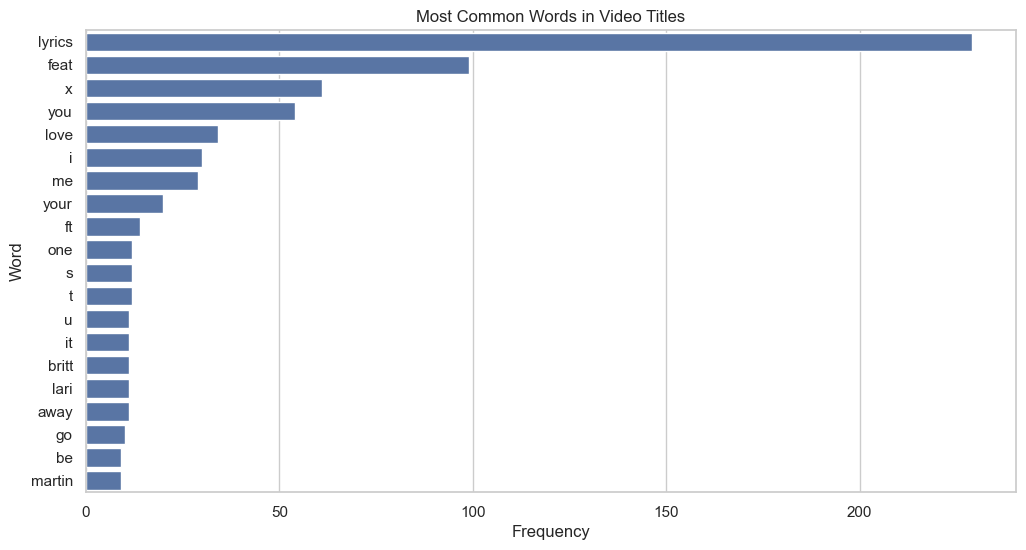

In [86]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("Most Common Words in Video Titles")

plt.show()

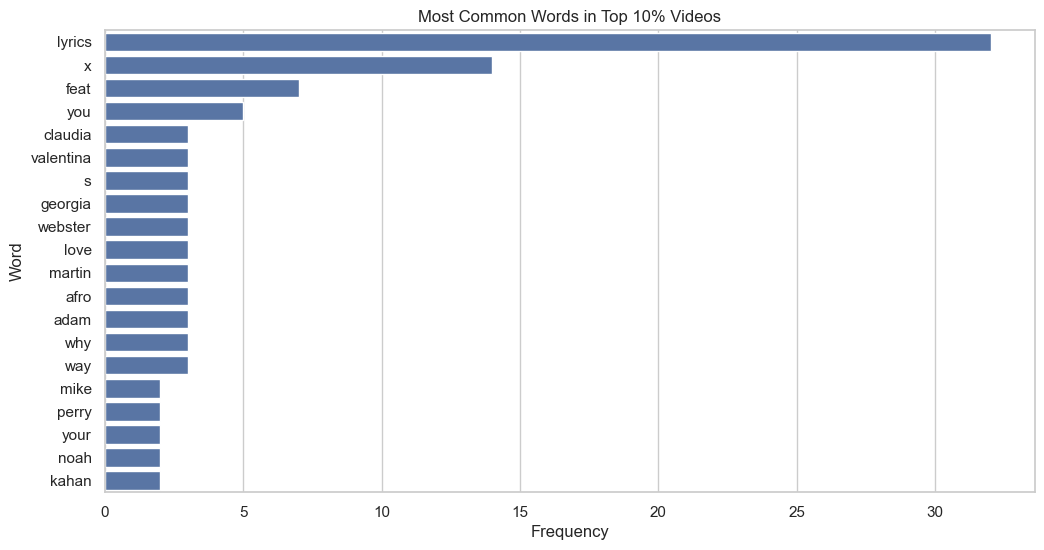

In [87]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_hit_words,
    x="Frequency",
    y="Word"
)

plt.title("Most Common Words in Top 10% Videos")

plt.show()

In [88]:
title_df["Title Score"] = (
    title_df["Has Lyrics"].astype(int)
    + title_df["Has Collaboration"].astype(int)
    + title_df["Has Brackets"].astype(int)
)

print(title_df[
    [
        "Video title",
        "Title Score"
    ]
].head())

                                     Video title  Title Score
1             Claudia Valentina - Candy (Lyrics)            2
2           Tom Gregory - Rather Be You (Lyrics)            2
3             Mike Perry - By Your Side (Lyrics)            2
4  Deacon - Long Run (Lyrics) feat. Nina Nesbitt            3
5                 Noah Kahan - Northern Attitude            0


In [89]:
print("="*80)
print("PHASE 6 : VIDEO TITLE INTELLIGENCE")
print("="*80)

print("""
OBJECTIVE

This phase analysed whether
video title structure influences
YouTube performance.

BUSINESS QUESTIONS

✓ Does 'Lyrics' improve performance?

✓ Do collaborations outperform solo artists?

✓ Are shorter titles better?

✓ Do brackets increase CTR?

✓ Which keywords occur most frequently
among successful uploads?

BUSINESS VALUE

These findings can directly guide:

• Metadata optimisation

• Future upload naming conventions

• Artist collaboration strategy

• SEO optimisation

• CTR improvement

NEXT PHASE

Phase 7 will build a Machine Learning model
to predict future video performance
using all engineered features.
""")

PHASE 6 : VIDEO TITLE INTELLIGENCE

OBJECTIVE

This phase analysed whether
video title structure influences
YouTube performance.

BUSINESS QUESTIONS

✓ Does 'Lyrics' improve performance?

✓ Do collaborations outperform solo artists?

✓ Are shorter titles better?

✓ Do brackets increase CTR?

✓ Which keywords occur most frequently
among successful uploads?

BUSINESS VALUE

These findings can directly guide:

• Metadata optimisation

• Future upload naming conventions

• Artist collaboration strategy

• SEO optimisation

• CTR improvement

NEXT PHASE

Phase 7 will build a Machine Learning model
to predict future video performance
using all engineered features.



In [90]:
print("=" * 100)
print("FRESH VIBES MUSIC ANALYTICS PROJECT")
print("Reverse Engineering YouTube Growth for a Future Independent Record Label")
print("=" * 100)

print("""
PROJECT OVERVIEW
--------------------------------------------------------------------------------
This project analyzed historical YouTube performance data from Fresh Vibes Music
to identify patterns that contribute to successful music releases.

The objective was not only to understand past performance but also to generate
business intelligence that can support future decisions for an independent
record label specializing in Deep House, Melodic House, and Ethno-Electronic music.
""")

print("=" * 100)
print("PROJECT PHASE SUMMARY")
print("=" * 100)

print("""
PHASE 1 — DATA CLEANING
✓ Removed invalid summary rows
✓ Converted columns into appropriate data types
✓ Cleaned missing values
✓ Standardized numerical features
✓ Verified dataset quality

--------------------------------------------------------------------------------

PHASE 2 — EXPLORATORY DATA ANALYSIS
✓ Statistical summary
✓ Distribution analysis
✓ Outlier detection
✓ Correlation analysis
✓ Business insight generation

Key Finding:
The channel follows a highly right-skewed distribution where a relatively
small number of uploads generate the majority of views, impressions,
and watch time.

--------------------------------------------------------------------------------

PHASE 3 — HIGH PERFORMER ANALYSIS

✓ Identified Top Performing uploads
✓ Compared successful videos with average uploads
✓ Reverse engineered algorithmic winners

Key Finding:
High-performing uploads receive substantially more impressions and
watch time, reinforcing the importance of recommendation-driven growth.

--------------------------------------------------------------------------------

PHASE 4 — TRACK DURATION ANALYSIS

✓ Duration categorization
✓ Performance comparison
✓ Duration distribution
✓ Duration scoring

Key Finding:
Track duration alone is not a strong linear predictor of success.
Performance depends on multiple interacting factors rather than
duration in isolation.

--------------------------------------------------------------------------------

PHASE 5 — CTR & IMPRESSION ANALYSIS

✓ CTR analysis
✓ Impression analysis
✓ CTR Bucketing
✓ Algorithmic Hit exploration

Key Finding:
Impressions are the strongest observable driver of total views.
CTR alone does not explain success but likely contributes to YouTube's
recommendation behaviour when combined with strong engagement.

--------------------------------------------------------------------------------

PHASE 6 — VIDEO TITLE INTELLIGENCE

✓ Title feature engineering
✓ Keyword analysis
✓ Title length analysis
✓ Metadata exploration

Key Finding:
Video metadata provides valuable optimisation opportunities.
Naming conventions, keywords and title structure can influence
discoverability and click behaviour.

""")

print("=" * 100)
print("OVERALL BUSINESS CONCLUSIONS")
print("=" * 100)

print("""

1. YouTube performance follows a Winner-Takes-Most distribution.

2. Recommendation system exposure (Impressions)
is the strongest measurable driver of Views.

3. Watch Time and Views show an extremely strong positive relationship,
highlighting audience engagement as a critical growth signal.

4. Track Duration alone does not determine success,
suggesting that content quality and audience response are more important
than length.

5. Video metadata (titles, keywords and structure)
offers opportunities for optimisation and should be continuously tested.

6. Viral uploads should not be treated as statistical outliers;
instead, they should be studied to understand repeatable success patterns.

7. Data-driven decision making can significantly improve
future music release strategies.

""")

print("=" * 100)
print("PROJECT IMPACT")
print("=" * 100)

print("""

This project demonstrates practical applications of:

• Data Cleaning

• Exploratory Data Analysis

• Feature Engineering

• Business Analytics

• Data Visualization

• Statistical Thinking

• Data Storytelling

using Python libraries including:

✓ Pandas
✓ NumPy
✓ Matplotlib
✓ Seaborn

""")

print("=" * 100)
print("FINAL CONCLUSION")
print("=" * 100)

print("""

Rather than analysing public music datasets,
this project leverages proprietary historical YouTube data
to generate actionable business intelligence.

The insights generated through this analysis can support:

• Future artist selection

• Track release planning

• Metadata optimisation

• Marketing strategies

• Audience growth

• Data-informed decision making

for the future Fresh Vibes independent record label.

Project Completed Successfully.
""")

print("=" * 100)

FRESH VIBES MUSIC ANALYTICS PROJECT
Reverse Engineering YouTube Growth for a Future Independent Record Label

PROJECT OVERVIEW
--------------------------------------------------------------------------------
This project analyzed historical YouTube performance data from Fresh Vibes Music
to identify patterns that contribute to successful music releases.

The objective was not only to understand past performance but also to generate
business intelligence that can support future decisions for an independent
record label specializing in Deep House, Melodic House, and Ethno-Electronic music.

PROJECT PHASE SUMMARY

PHASE 1 — DATA CLEANING
✓ Removed invalid summary rows
✓ Converted columns into appropriate data types
✓ Cleaned missing values
✓ Standardized numerical features
✓ Verified dataset quality

--------------------------------------------------------------------------------

PHASE 2 — EXPLORATORY DATA ANALYSIS
✓ Statistical summary
✓ Distribution analysis
✓ Outlier detection
✓ Corre